# Polynomial Regression Assignment Using Insurance Dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv(r"/content/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [3]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [6]:
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
le_smoker = LabelEncoder()

df['sex'] = le_sex.fit_transform(df['sex'])
df['smoker'] = le_smoker.fit_transform(df['smoker'])


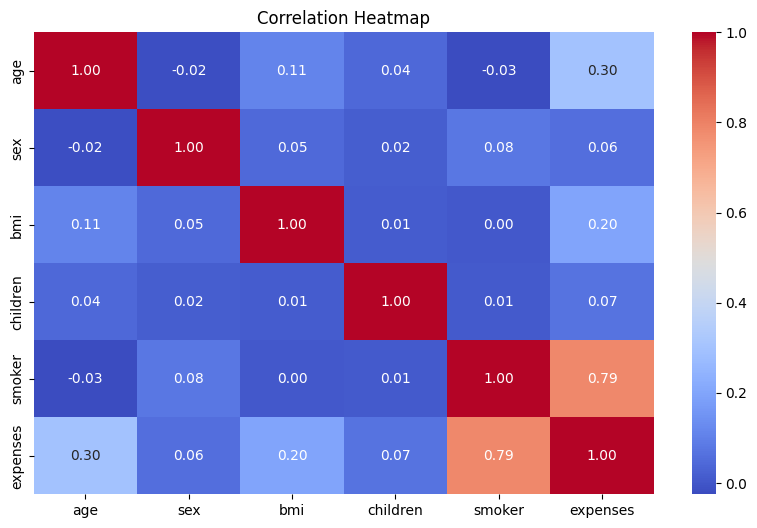

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

In [8]:
df["obese_smoker"] = ((df['bmi'] >= 30) & (df['smoker'] == 1)).astype(int)

In [9]:
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 100], labels=['young', 'middle_aged', 'senior'])

In [10]:
df['bmi_cat'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 100], labels=['underweight', 'normal', 'overweight', 'obese'])

In [11]:
df['has_children'] = (df['children'] > 0).astype(int)

In [12]:
check = df.copy()

In [13]:
df

,age,sex,bmi,children,smoker,region,expenses,obese_smoker,age_group,bmi_cat,has_children
0,19,0,27.9,0,1,southwest,16884.92,0,young,overweight,0
1,18,1,33.8,1,0,southeast,1725.55,0,young,obese,1
2,28,1,33.0,3,0,southeast,4449.46,0,young,obese,1
3,33,1,22.7,0,0,northwest,21984.47,0,middle_aged,normal,0
4,32,1,28.9,0,0,northwest,3866.86,0,middle_aged,overweight,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,31.0,3,0,northwest,10600.55,0,middle_aged,obese,1
1334,18,0,31.9,0,0,northeast,2205.98,0,young,obese,0
1335,18,0,36.9,0,0,southeast,1629.83,0,young,obese,0
1336,21,0,25.8,0,0,southwest,2007.95,0,young,overweight,0


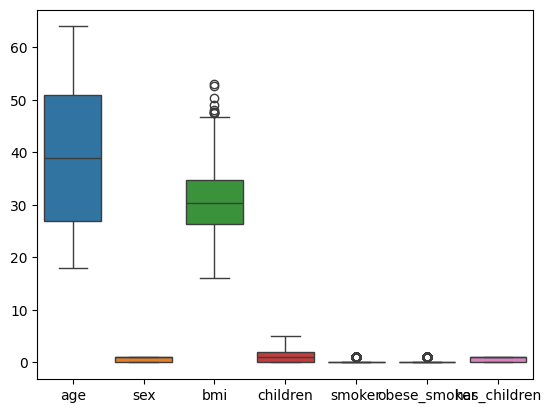

In [14]:

check = check.drop('expenses', axis=1)
sns.boxplot(data=check)
plt.show()

In [15]:
df

,age,sex,bmi,children,smoker,region,expenses,obese_smoker,age_group,bmi_cat,has_children
0,19,0,27.9,0,1,southwest,16884.92,0,young,overweight,0
1,18,1,33.8,1,0,southeast,1725.55,0,young,obese,1
2,28,1,33.0,3,0,southeast,4449.46,0,young,obese,1
3,33,1,22.7,0,0,northwest,21984.47,0,middle_aged,normal,0
4,32,1,28.9,0,0,northwest,3866.86,0,middle_aged,overweight,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,31.0,3,0,northwest,10600.55,0,middle_aged,obese,1
1334,18,0,31.9,0,0,northeast,2205.98,0,young,obese,0
1335,18,0,36.9,0,0,southeast,1629.83,0,young,obese,0
1336,21,0,25.8,0,0,southwest,2007.95,0,young,overweight,0


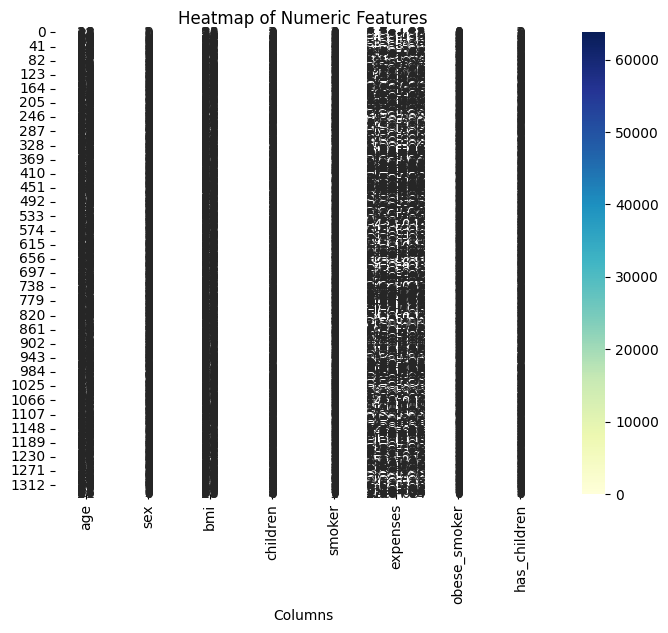

In [16]:
plt.figure(figsize=(8, 6))
# Selects only integer and float columns, leaving 'southwest' behind
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df, annot=True, cmap="YlGnBu", linewidths=0.5)

plt.title("Heatmap of Numeric Features")
plt.xlabel("Columns")
plt.show()

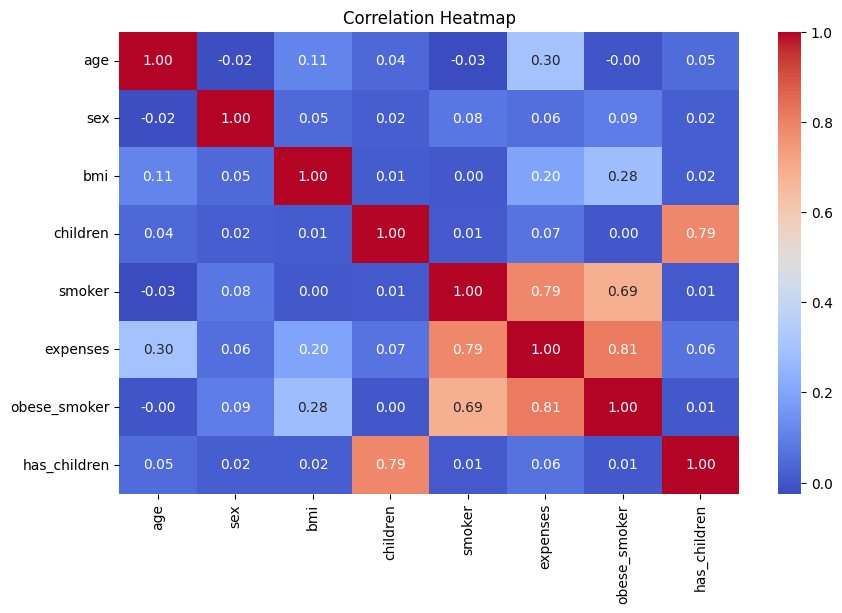

In [17]:
plt.figure(figsize=(10, 6))
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

In [18]:

X = df.drop('expenses', axis=1)
y = df['expenses']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1070, 10) (268, 10) (1070,) (268,)


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder, RobustScaler, PolynomialFeatures

class ColumnTransformation(BaseEstimator, TransformerMixin):

    def __init__(self, columns_to_encode=None):

        if columns_to_encode is None:
            columns_to_encode = ['region', 'age_group', 'bmi_cat']

        self.columns_to_encode = columns_to_encode
        self.encoded_columns_ = None

    def fit(self, X, y=None):

        X_encoded = pd.get_dummies(
            X[self.columns_to_encode],
            drop_first=True
        )

        self.encoded_columns_ = list(X_encoded.columns)

        return self

    def transform(self, X):

        X_out = X.copy()

        X_dummies = pd.get_dummies(
            X_out[self.columns_to_encode],
            drop_first=True
        )

        X_dummies = X_dummies.reindex(
            columns=self.encoded_columns_,
            fill_value=0
        )

        X_out = X_out.drop(columns=self.columns_to_encode)

        X_out = pd.concat([X_out, X_dummies], axis=1)

        # ensure purely numeric
        X_out = X_out.astype(float)

        return X_out

In [22]:
# transformer = ColumnTransformation()

# X_train_transformed = transformer.fit_transform(X_train)

# print("Transformed Training Data:")
# print(X_train_transformed.isna().sum())


In [61]:
# print(X_train_transformed.dtypes)

age                      float64
sex                      float64
bmi                      float64
children                 float64
smoker                   float64
obese_smoker             float64
has_children             float64
region_northwest         float64
region_southeast         float64
region_southwest         float64
age_group_middle_aged    float64
age_group_senior         float64
bmi_cat_normal           float64
bmi_cat_overweight       float64
bmi_cat_obese            float64
dtype: object


In [63]:
# print(X_train_transformed.isnull().any().any())

False


In [65]:
# print(np.isinf(X_train_transformed.to_numpy()).any())

False


In [53]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# from sklearn.preprocessing import RobustScaler

# scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# poly = PolynomialFeatures(degree=2, include_bias=False)
# X_poly = poly.fit_transform(X_train_scaled)
# X_poly_test = poly.fit_transform(X_test_scaled)

# print(X_poly.shape)


In [67]:
# scaler = RobustScaler()

# X_scaled = scaler.fit_transform(X_train_transformed)

# print(X_scaled.dtype)


float64


In [70]:
# print(np.isnan(X_scaled).any())

False


In [73]:
# from sklearn.preprocessing import PolynomialFeatures

# poly = PolynomialFeatures(degree=2)

# X_poly = poly.fit_transform(X_scaled)

# print(np.isnan(X_poly).any())


(1070, 136)
False


# **Model PipeLine**

In [23]:
pipe = Pipeline([
    ('encoding', ColumnTransformation()),
    ('scaler', RobustScaler()),
    ('poly_features', PolynomialFeatures(include_bias=False)),
    ('lr', LinearRegression())
])

In [24]:
param_grid = {
  'encoding__columns_to_encode': [['region', 'age_group', 'bmi_cat']],
  'scaler__with_centering': [True, False],
  'scaler__with_scaling': [True, False],
  'poly_features__degree': [1, 2],
  'poly_features__interaction_only': [True, False],
  'lr__fit_intercept': [True, False]
}

In [25]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)


In [26]:
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('encoding',
                                        ColumnTransformation(columns_to_encode=['region',
                                                                                'age_group',
                                                                                'bmi_cat'])),
                                       ('scaler', RobustScaler()),
                                       ('poly_features',
                                        PolynomialFeatures(include_bias=False)),
                                       ('lr', LinearRegression())]),
             n_jobs=-1,
             param_grid={'encoding__columns_to_encode': [['region', 'age_group',
                                                          'bmi_cat']],
                         'lr__fit_intercept': [True, False],
                         'poly_features__degree': [1, 2],
                         'poly_features__interaction_only': [True, False],
                         'scaler__with_centering': [True, False],
                         'scaler__with_scaling': [True, False]},
             scoring='r2', verbose=2)

In [27]:
print(f"Best parameters found: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Best parameters found: {'encoding__columns_to_encode': ['region', 'age_group', 'bmi_cat'], 'lr__fit_intercept': True, 'poly_features__degree': 1, 'poly_features__interaction_only': True, 'scaler__with_centering': True, 'scaler__with_scaling': True}


In [28]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("--- Model Accuracy Evaluation ---")
print(f"Train R² Score: {r2_train:.4f}")
print(f"Test R² Score:  {r2_test:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

--- Model Accuracy Evaluation ---
Train R² Score: 0.8634
Test R² Score:  0.8763
Best Parameters: {'encoding__columns_to_encode': ['region', 'age_group', 'bmi_cat'], 'lr__fit_intercept': True, 'poly_features__degree': 1, 'poly_features__interaction_only': True, 'scaler__with_centering': True, 'scaler__with_scaling': True}


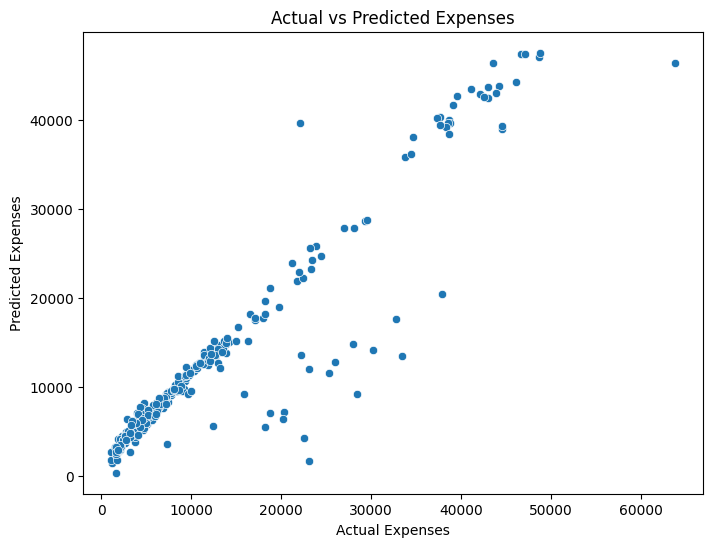

In [29]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred
)

plt.xlabel("Actual Expenses")
plt.ylabel("Predicted Expenses")
plt.title("Actual vs Predicted Expenses")

plt.show()

In [33]:
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, PolynomialFeatures

# 1. Update the Pipeline with ElasticNet
pipe = Pipeline([
    ('label_encodeing', ColumnTransformation()),
    ('robust_scaler', RobustScaler()),
    ('poly_featurs', PolynomialFeatures(degree=2, include_bias=False)), # interaction terms created here
    ('regressor', ElasticNet(max_iter=5000))        # Replaced lr with regularized model
])

# 2. Update your Param Grid to test L1 vs L2 ratios
param_grid = {
    'poly_featurs__degree': [2,3],
    'poly_featurs__interaction_only': [True], # strongly recommended for dummy features

    # ElasticNet Hyperparameters
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0],       # Penalty strength (higher = more regularization)
    'regressor__l1_ratio': [0.1, 0.2, 0.5, 0.8, 1.0]  # 0.0 is pure L2 (Ridge), 1.0 is pure L1 (Lasso)
}

In [34]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [35]:
grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 40 candidates, totalling 120 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('label_encodeing',
                                        ColumnTransformation(columns_to_encode=['region',
                                                                                'age_group',
                                                                                'bmi_cat'])),
                                       ('robust_scaler', RobustScaler()),
                                       ('poly_featurs',
                                        PolynomialFeatures(include_bias=False)),
                                       ('regressor',
                                        ElasticNet(max_iter=5000))]),
             n_jobs=-1,
             param_grid={'poly_featurs__degree': [2, 3],
                         'poly_featurs__interaction_only': [True],
                         'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
                         'regressor__l1_ratio': [0.1, 0.2, 0.5, 0.8, 1.0]},
             scoring='r2', verbose=2)

In [36]:
print(f"Best parameters found: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Best parameters found: {'poly_featurs__degree': 2, 'poly_featurs__interaction_only': True, 'regressor__alpha': 10.0, 'regressor__l1_ratio': 1.0}


# **R2 Score**

In [37]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("--- Model Accuracy Evaluation ---")
print(f"Train R² Score: {r2_train:.4f}")
print(f"Test R² Score:  {r2_test:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

--- Model Accuracy Evaluation ---
Train R² Score: 0.8731
Test R² Score:  0.8800
Best Parameters: {'poly_featurs__degree': 2, 'poly_featurs__interaction_only': True, 'regressor__alpha': 10.0, 'regressor__l1_ratio': 1.0}


# **Old Result:**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
n = len(X_test)
m = 3
r2_adj = 1 - ((1-r2)*(n-1)/(n-m-1))
print("MAE:", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2 Score: ", r2)
print("R2 Adjusted: ", r2_adj)
print("Mean of Sales Column: ", df['expenses'].mean())

MAE: 2913.231688047174
MSE:  22296328.510538895
RMSE:  4721.8988246825975
R2 Score:  0.8563831860313623
R2 Adjusted:  0.8547511767817187
Mean of Sales Column:  13270.422414050823
